# **Territorial commitment from tracking data**

The main analysis, built entirely from StatsBomb event data, finds that most teams press more when playing at home than away — a Bourgeois-like pattern of territorial behavior across four European leagues. Tracking data offers an independent way to check whether that same pattern shows up in raw player positions rather than in logged defensive actions.

This notebook builds a tracking-data metric for that purpose — **territorial fraction**: the share of a team's own outfield players standing in the opponent's half at moments when the opponent has the ball there — and tests it against a single match of Metrica Sports' openly available tracking data.

Metrica's sample match is anonymized and has no connection to the StatsBomb sample, so this can only test whether the *general* pattern — home sides being more territorially committed than away sides — is visible in independent tracking data, not corroborate any specific team's numbers.

This notebook uses Metrica Sports' Sample Game 2 tracking data. The match stays close throughout — 1-1 at 35 minutes, 2-2 at 76 minutes, decided only in the final 13 minutes (3-2) — which makes it a reasonably clean case for reading territorial behavior as *style* rather than as a reaction to an already-decided scoreline, since neither team is forced into pure game-management or pure desperation for long stretches.

# Data

Metrica Sports publish two anonymized matches of raw tracking data on GitHub (`metrica-sports/sample-data`): player positions at 25 frames per second for all 22 outfield players plus the ball, alongside an event log (passes, shots, recoveries, etc.) for the same match. Player and team identities are anonymized ("Home"/"Away", "Player1"..."Player28"), and there is no metadata identifying which real teams or players these are.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
%config InlineBackend.figure_format = 'retina'


os.makedirs("data/tracking_raw", exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_2"
FILES = {
    "data/tracking_raw/home_game2.csv": f"{BASE_URL}/Sample_Game_2_RawTrackingData_Home_Team.csv",
    "data/tracking_raw/away_game2.csv": f"{BASE_URL}/Sample_Game_2_RawTrackingData_Away_Team.csv",
    "data/tracking_raw/events_game2.csv": f"{BASE_URL}/Sample_Game_2_RawEventsData.csv",
}

for path, url in FILES.items():
    if not os.path.exists(path):
        pd.read_csv(url).to_csv(path, index=False)

print("data ready")

data ready


# Data problems and caveats encountered

Five issues shape how much to trust the results below.

**1. No player role labels.** Players are anonymized with no position information — the goalkeeper has to be identified from the data itself.

**2. No per-frame possession tag.** Possession is inferred from the separate event log, which only tags it at the moments an event occurs; gaps between events are filled forward.

**3. Direction of play is not given explicitly.** A team's own goal can be at either end depending on the period, since teams switch ends at half-time — detected here from the identified goalkeeper's average position.

**4. The match clock is a trap.** `Time [s]` is a single continuous clock across both periods, not one that resets at half-time.

**5. This is a single match.** Metrica Sports publishes only two openly available tracking matches in total, and this notebook uses one of them. Whatever it finds below is a single-match illustration, not a result that generalizes — the goal is to test whether the event-data pattern is *visible* in tracking data at all, not to establish it independently.

# Loading and parsing the tracking data

Each tracking file has a three-row header (team name, shirt number, column label) followed by one row per frame: `Period`, `Frame`, `Time [s]`, then an (x, y) pair for each of 14 players, then an (x, y) pair for the ball. Parsed here into a tidy wide table with one `player_x` / `player_y` column pair per player.

In [2]:
def load_tracking(path):
    raw = pd.read_csv(path, skiprows=2, header=0)
    header_row = pd.read_csv(path, nrows=0, skiprows=2).columns.tolist()
    player_labels = [c for c in header_row if c.startswith("Player")]
    new_cols = ["Period", "Frame", "Time"]
    for p in player_labels:
        new_cols += [f"{p}_x", f"{p}_y"]
    new_cols += ["ball_x", "ball_y"]
    raw.columns = new_cols
    return raw, player_labels


home, home_players = load_tracking("data/tracking_raw/home_game2.csv")
away, away_players = load_tracking("data/tracking_raw/away_game2.csv")

print(f"Home: {len(home):,} frames, {len(home_players)} players tracked")
print(f"Away: {len(away):,} frames, {len(away_players)} players tracked")
home.head()

Home: 141,156 frames, 14 players tracked
Away: 141,156 frames, 12 players tracked


,Period,Frame,Time,Player11_x,Player11_y,Player1_x,Player1_y,Player2_x,Player2_y,Player3_x,...,Player10_x,Player10_y,Player12_x,Player12_y,Player13_x,Player13_y,Player14_x,Player14_y,ball_x,ball_y
0,1,1,0.04,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.08,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,0.12,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,0.16,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,0.20,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Detecting the goalkeeper and direction of play

No position labels are provided, but a goalkeeper is easy to find without one: across a whole period, no outfield player stays anywhere near as close to one end of the pitch as a goalkeeper does. Taking the player whose average x-position is most extreme identifies the goalkeeper, and which end they sit closest to identifies which goal that team is defending in that period.

In [3]:
def detect_own_goal_side(df, players, period):
    sub = df[df.Period == period]
    avg_x = {p: sub[f"{p}_x"].mean() for p in players if sub[f"{p}_x"].notna().any()}
    goalkeeper = min(avg_x, key=lambda p: min(avg_x[p], 1 - avg_x[p]))
    own_goal_side = 0 if avg_x[goalkeeper] < 0.5 else 1
    return goalkeeper, own_goal_side


home_gk_by_period, home_side_by_period = {}, {}
away_gk_by_period, away_side_by_period = {}, {}
for period in [1, 2]:
    gk, side = detect_own_goal_side(home, home_players, period)
    home_gk_by_period[period], home_side_by_period[period] = gk, side
    gk2, side2 = detect_own_goal_side(away, away_players, period)
    away_gk_by_period[period], away_side_by_period[period] = gk2, side2

print("Home goalkeeper:", home_gk_by_period, "| own-goal side (0=x0, 1=x1):", home_side_by_period)
print("Away goalkeeper:", away_gk_by_period, "| own-goal side (0=x0, 1=x1):", away_side_by_period)

Home goalkeeper: {1: 'Player11', 2: 'Player11'} | own-goal side (0=x0, 1=x1): {1: 1, 2: 0}
Away goalkeeper: {1: 'Player25', 2: 'Player25'} | own-goal side (0=x0, 1=x1): {1: 0, 2: 1}


Both teams keep the same goalkeeper across both periods, and their own-goal side flips between period 1 and period 2, exactly as expected when two teams switch ends at half-time.

# Measuring territorial commitment

This measures something closer to the main analysis's forward press rate than a positional line would: **how many of a team's own outfield players (excluding the goalkeeper) are currently positioned in the opponent's half**, at each frame. Positions are re-expressed as distance from *that team's own goal* using the side detected above, so a value above 0.5 always means "in the opponent's half," regardless of period or physical end of the pitch.

This captures collective commitment — how many players a team is willing to push forward to contest space — which is the tracking-data property closest in spirit to forward press rate's own "willingness to commit into the opponent's territory," even though one is built from positions and the other from logged actions.

In [4]:
def compute_territorial_presence(df, players, gk_by_period, side_by_period):
    n_players_forward = np.full(len(df), np.nan)
    n_players_tracked = np.full(len(df), np.nan)
    ball_in_opp_half = np.full(len(df), False)
    for period in df.Period.unique():
        mask = (df.Period == period).values
        goalkeeper = gk_by_period[period]
        own_goal_side = side_by_period[period]
        outfield = [p for p in players if p != goalkeeper]
        xs = df.loc[mask, [f"{p}_x" for p in outfield]].to_numpy()
        distance_from_own_goal = xs if own_goal_side == 0 else (1 - xs)
        n_players_forward[mask] = np.nansum(distance_from_own_goal > 0.5, axis=1)
        n_players_tracked[mask] = np.sum(~np.isnan(distance_from_own_goal), axis=1)
        ball_x = df.loc[mask, "ball_x"].to_numpy()
        ball_dist = ball_x if own_goal_side == 0 else (1 - ball_x)
        ball_in_opp_half[mask] = ball_dist > 0.5
    return n_players_forward, n_players_tracked, ball_in_opp_half


for _df, _players, _gk, _side in [
    (home, home_players, home_gk_by_period, home_side_by_period),
    (away, away_players, away_gk_by_period, away_side_by_period),
]:
    n_fwd, n_tracked, ball_fwd = compute_territorial_presence(_df, _players, _gk, _side)
    _df["n_players_forward"] = n_fwd
    _df["territorial_fraction"] = n_fwd / n_tracked
    _df["ball_in_opp_half"] = ball_fwd
    _df["match_min"] = _df["Time"] / 60.0  # Time [s] is a single continuous clock across both periods

print("Home territorial fraction, overall mean:", round(home["territorial_fraction"].mean(), 3))
print("Away territorial fraction, overall mean:", round(away["territorial_fraction"].mean(), 3))

Home territorial fraction, overall mean: 0.426
Away territorial fraction, overall mean: 0.437


# Restricting to when the opponent has the ball in their own half

This is only meaningful as an *aggression* signal under a specific condition: the opponent has the ball, **and** the ball itself is in the opponent's own half — i.e. the opponent is building out from a deep, contestable position. Territorial presence while a team's own attack is in the opponent's half reflects normal attacking shape, not a defensive choice; possession is inferred the same way as before, by forward-filling the event log's team tags across frames.

In [5]:
events = pd.read_csv("data/tracking_raw/events_game2.csv")

event_starts = (
    events[["Start Frame", "Team"]]
    .dropna()
    .sort_values("Start Frame")
    .drop_duplicates("Start Frame", keep="first")
)

max_frame = max(home["Frame"].max(), away["Frame"].max())
possession = pd.Series(index=pd.RangeIndex(1, max_frame + 1), dtype=object)
possession.loc[event_starts["Start Frame"].values] = event_starts["Team"].values
possession = possession.ffill()

home["opponent_has_ball"] = possession.reindex(home["Frame"]).values == "Away"
away["opponent_has_ball"] = possession.reindex(away["Frame"]).values == "Home"

print("Frames with each team in possession:")
print(possession.value_counts())

Frames with each team in possession:
Home    72964
Away    68142
Name: count, dtype: int64


# Overall numbers: home vs. away

In [23]:
home_restricted = home[home["opponent_has_ball"] & home["ball_in_opp_half"]]
away_restricted = away[away["opponent_has_ball"] & away["ball_in_opp_half"]]

home_summary = home_restricted["territorial_fraction"].mean()
away_summary = away_restricted["territorial_fraction"].mean()
home_n_forward = home_restricted["n_players_forward"].mean()
away_n_forward = away_restricted["n_players_forward"].mean()

print(f"Home — {len(home_restricted):,} qualifying frames ({100*len(home_restricted)/len(home):.1f}% of match)")
print(f"Home — mean territorial fraction: {home_summary:.4f} ({home_n_forward:.2f} of 10 outfield players)")
print()
print(f"Away — {len(away_restricted):,} qualifying frames ({100*len(away_restricted)/len(away):.1f}% of match)")
print(f"Away — mean territorial fraction: {away_summary:.4f} ({away_n_forward:.2f} of 10 outfield players)")

Home — 21,616 qualifying frames (15.3% of match)
Home — mean territorial fraction: 0.5048 (5.05 of 10 outfield players)

Away — 20,231 qualifying frames (14.3% of match)
Away — mean territorial fraction: 0.5297 (5.30 of 10 outfield players)


Home commits an average of 5.05 of its ~10 outfield players forward when pressing Away deep in Away's own half (happening in 15.3% of the match); Away commits 5.30 in the mirror situation (14.3% of the match). In fraction terms: a territorial fraction of 0.505 for Home versus 0.530 for Away.

# Does this match the event-data story?

The main event-based analysis found that 75 of 80 teams (93.8%) across four European leagues showed a higher forward press rate at home than away, a highly significant effect in every league individually — the Bourgeois pattern of aggressive-at-home, passive-away.

This single match points the other way. Away is very slightly *more* territorially committed than Home (0.530 vs. 0.505), not less. The gap is small, and this is one match rather than a season-long sample, but it's still worth taking seriously rather than waving away — if territorial fraction is a genuine tracking-data analogue of forward press rate, it should broadly agree with the direction event data finds, and here it doesn't.

# Investigating the mismatch: how does commitment evolve over the match?

One candidate explanation is that territorial fraction isn't a stable team trait at all, but something that moves with match events — in particular, the scoreline. Plotting it over time, against when goals actually happened, is the first way to check.

A 10-minute rolling average of territorial fraction, restricted to the qualifying frames above, split into two panels (Home and Away) to avoid the confusing overlap that comes from plotting both on one axis — since possession changes hands roughly every few seconds, both teams' restricted series are populated across almost the entire match, and a single combined plot makes it look like both teams are somehow pressing simultaneously. Goals are marked as vertical dotted lines, colored by which team scored, so spikes in territorial commitment can be read directly against match events rather than guessed at.

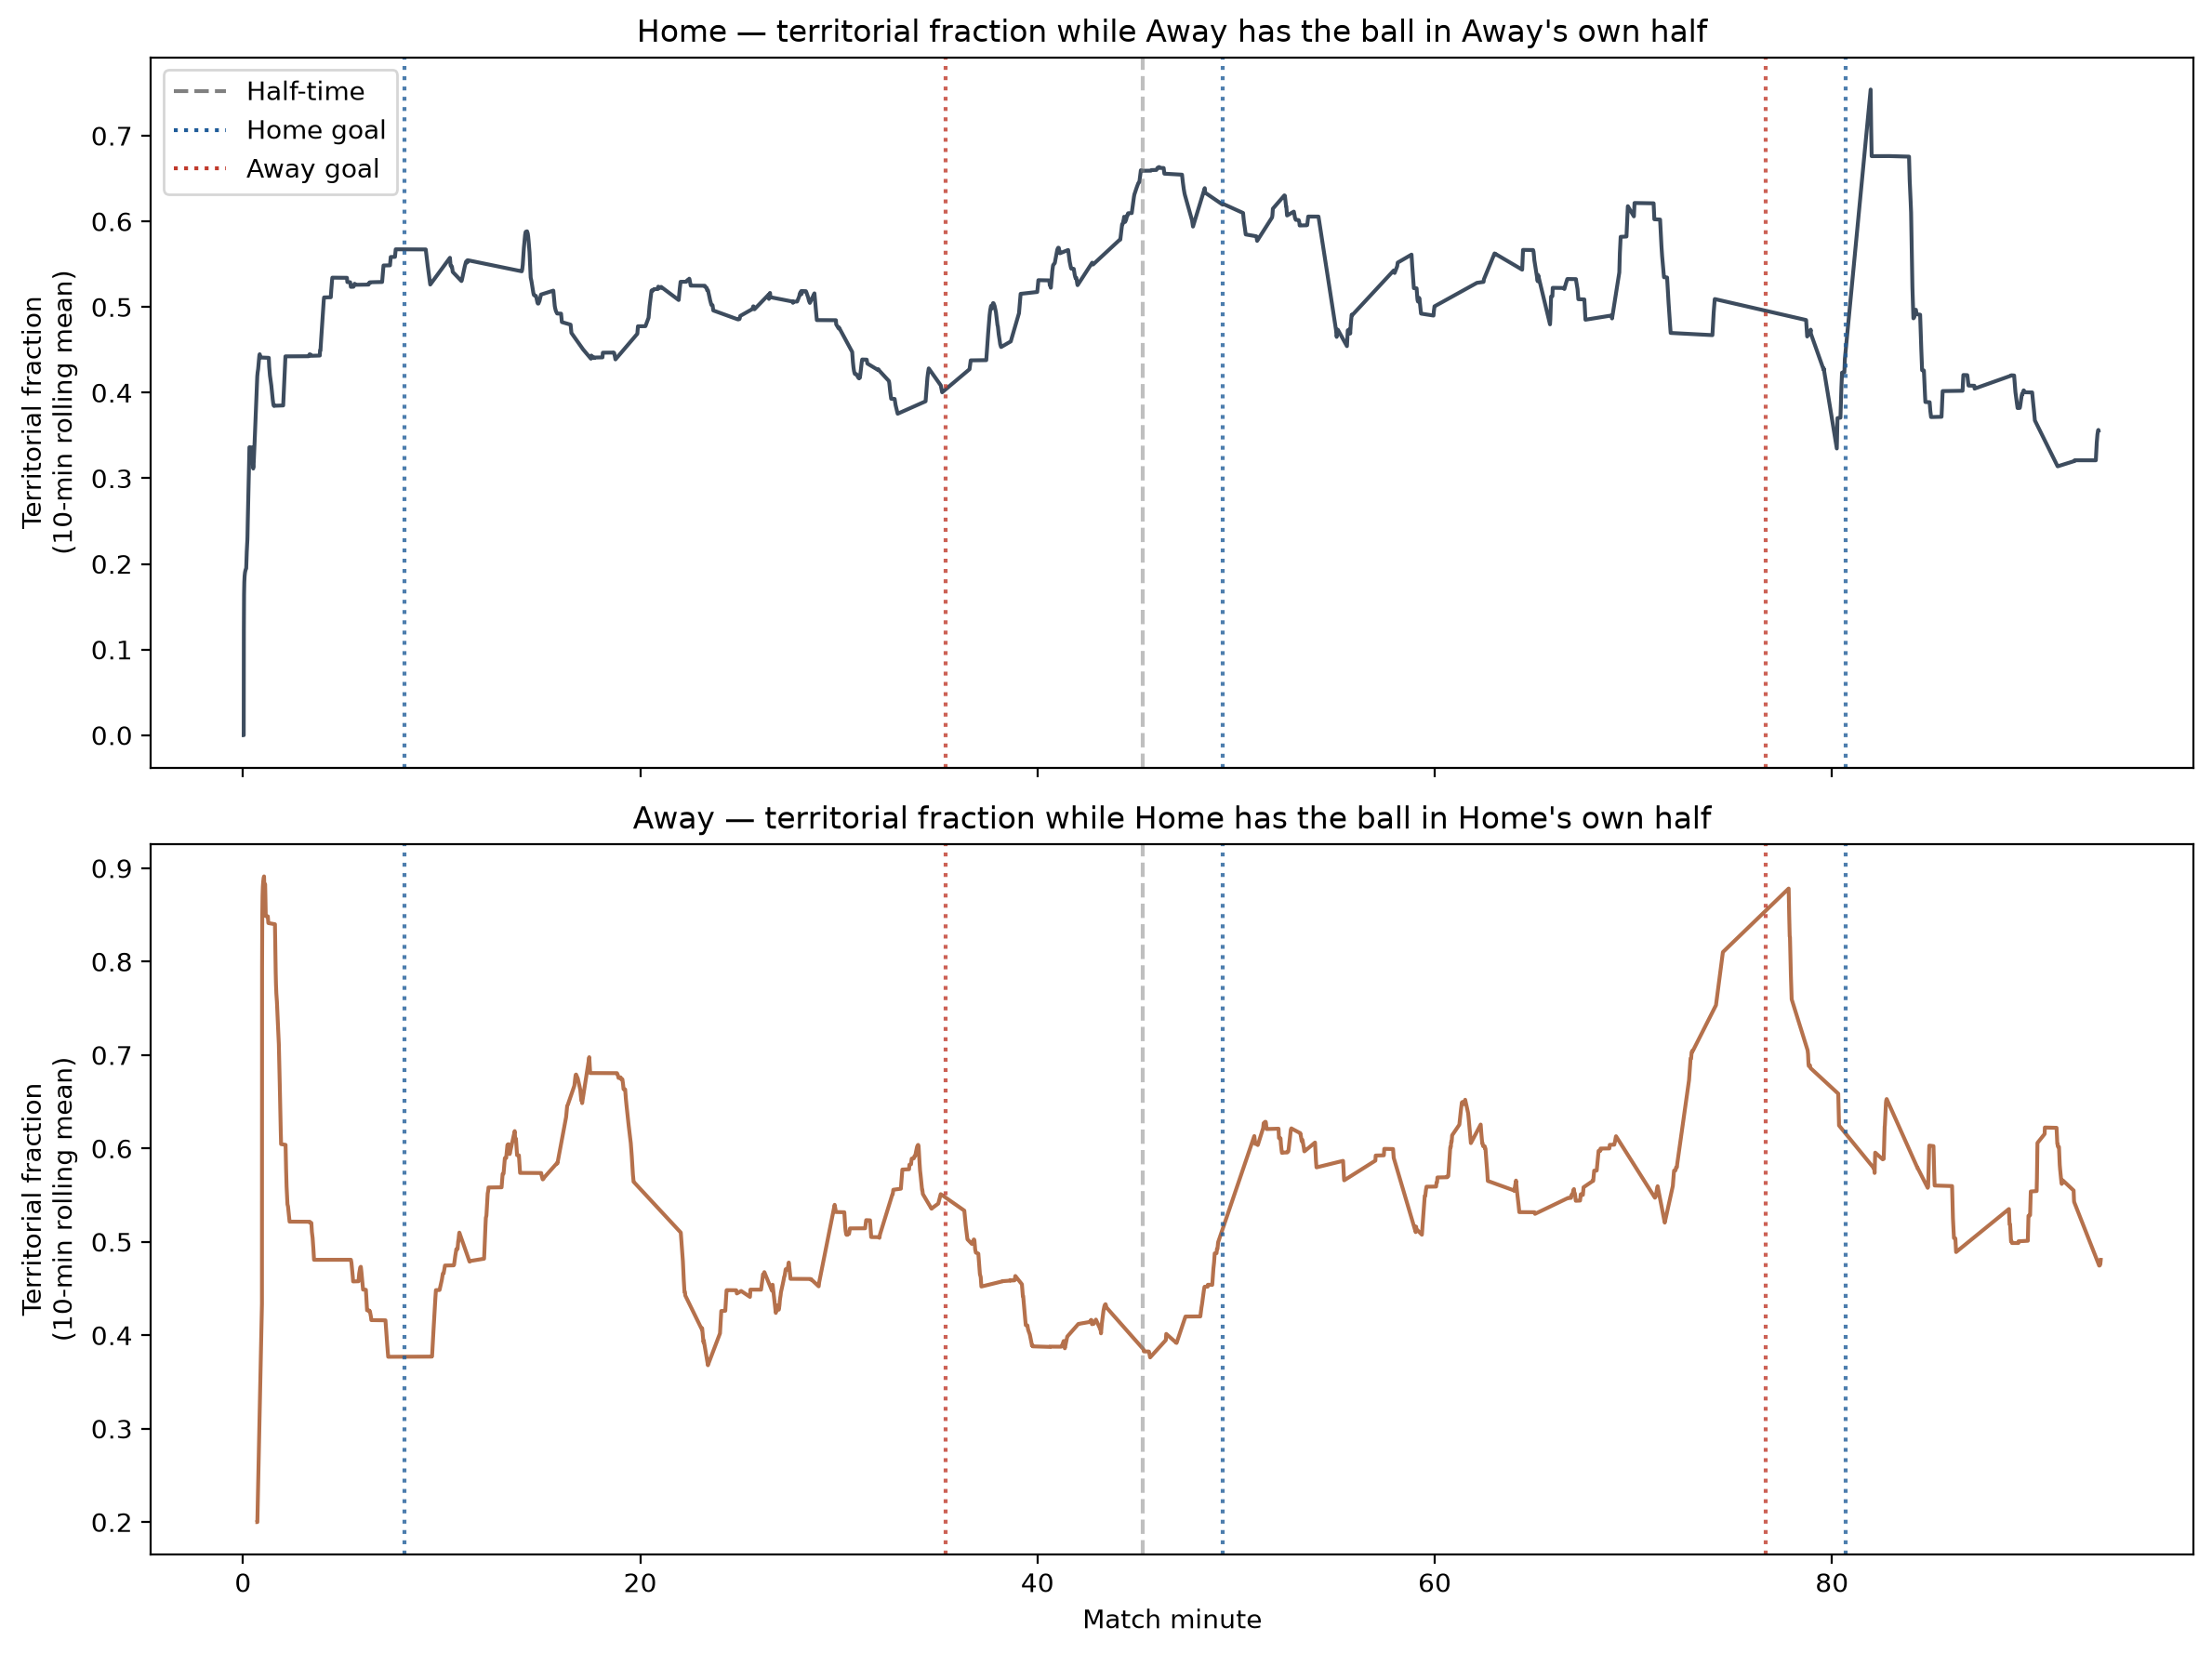

In [7]:
def rolling_territorial_fraction(df, window_minutes=10):
    sub = (
        df.loc[df["opponent_has_ball"] & df["ball_in_opp_half"], ["match_min", "territorial_fraction"]]
        .dropna()
        .sort_values("match_min")
        .reset_index(drop=True)
    )
    time_index = pd.to_timedelta(sub["match_min"], unit="m")
    rolled = pd.Series(sub["territorial_fraction"].values, index=time_index).rolling(f"{window_minutes}min").mean()
    return sub["match_min"].values, rolled.values


home_x, home_rolled = rolling_territorial_fraction(home)
away_x, away_rolled = rolling_territorial_fraction(away)

half_time_minute = home.loc[home.Period == 1, "match_min"].max()

home_goal_minutes = [8.134667, 49.322000, 80.684667]
away_goal_minutes = [35.366000, 76.672667]

fig, (ax_home, ax_away) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

ax_home.plot(home_x, home_rolled, color="#3D4C5E")
ax_away.plot(away_x, away_rolled, color="#B5714C")

for ax in (ax_home, ax_away):
    ax.axvline(half_time_minute, color="grey", linestyle="--", alpha=0.5)
    for g in home_goal_minutes:
        ax.axvline(g, color="#1F5C99", linestyle=":", alpha=0.8)
    for g in away_goal_minutes:
        ax.axvline(g, color="#C0392B", linestyle=":", alpha=0.8)

ax_home.set_title("Home — territorial fraction while Away has the ball in Away's own half")
ax_away.set_title("Away — territorial fraction while Home has the ball in Home's own half")
ax_home.set_ylabel("Territorial fraction\n(10-min rolling mean)")
ax_away.set_ylabel("Territorial fraction\n(10-min rolling mean)")
ax_away.set_xlabel("Match minute")

legend_elements = [
    Line2D([0], [0], color="grey", linestyle="--", label="Half-time"),
    Line2D([0], [0], color="#1F5C99", linestyle=":", label="Home goal"),
    Line2D([0], [0], color="#C0392B", linestyle=":", label="Away goal"),
]
ax_home.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.show()

The clearest feature in both panels is the shared peak in the 77-82 minute window — right where Away's equalizer (76.7') meets Home's immediate response (80.7'), the only stretch of the match where the score is actually changing hands. Away's fraction climbs from around 0.5 near minute 68 to its match peak of 0.878 at minute 77.8, exactly as it draws level; Home's climbs to its own peak of 0.754 at minute 82, just after retaking the lead. Both teams commit the most numbers forward precisely when the result is undecided or has just flipped, not when it's settled.

That's consistent with scoreline, not fixed team style, driving at least part of what territorial fraction picks up. Away's other notable feature — a trough of 0.368 around minute 23, while already 1-0 down — shows the relationship isn't a simple 'more committed the longer you trail': there's a settling-in period after an early goal before pressing intensifies. The state a team is actually *in* — leading, trailing, or level — looks like a better candidate explanation than time spent trailing on its own, which the next section checks directly.

In [8]:
def score_diff_at(match_min):
    h_goals = sum(1 for g in home_goal_minutes if g <= match_min)
    a_goals = sum(1 for g in away_goal_minutes if g <= match_min)
    return h_goals - a_goals


home_restricted = home_restricted.copy()
away_restricted = away_restricted.copy()
home_restricted["score_diff"] = home_restricted["match_min"].apply(score_diff_at)
away_restricted["score_diff"] = away_restricted["match_min"].apply(score_diff_at)

home_state = home_restricted["score_diff"].apply(lambda d: "Leading" if d > 0 else "Tied")
away_state = away_restricted["score_diff"].apply(lambda d: "Trailing" if d > 0 else "Tied")

home_by_state = home_restricted.groupby(home_state)["territorial_fraction"].agg(["mean", "count"])
away_by_state = away_restricted.groupby(away_state)["territorial_fraction"].agg(["mean", "count"])

print("Home territorial fraction by game state:")
print(home_by_state)
print()
print("Away territorial fraction by game state:")
print(away_by_state)

Home territorial fraction by game state:
                mean  count
score_diff                 
Leading     0.452210  14028
Tied        0.602056   7588

Away territorial fraction by game state:
                mean  count
score_diff                 
Tied        0.420498   6259
Trailing    0.578686  13972


Home's territorial fraction is 0.452 while leading (n=14,028 frames) but rises to 0.602 while tied (n=7,588) — lower, not higher, when comfortably ahead. Away's is the mirror image: 0.579 while trailing (n=13,972) against 0.420 while tied (n=6,259) — higher when chasing the game, lower when level.

That reframes the overall numbers. Home spent about two-thirds of its qualifying frames leading, which pulls its overall average down toward 0.452; Away spent about two-thirds of its trailing, which pulls its overall average up toward 0.579. The raw 0.505-vs-0.530 gap is small precisely because these opposite scoreline effects are pulling against each other inside a single overall mean.

Comparing like with like — both teams' figures restricted to the moments they were actually level — flips the story back the other way: Home's tied-state fraction (0.602) is well above Away's tied-state fraction (0.420), the same direction the event-data finding predicts. Once scoreline is held constant, this one match's tracking data agrees with the season-long event-data pattern; the raw, unconditional numbers didn't, because they were never comparing like with like in the first place.

# Validating territorial fraction against defensive line height

Territorial fraction is a deliberately novel metric built for this project, which raises an obvious question: does it actually behave like a sensible measure of territorial aggression, or could the mismatch above just as easily be a flaw in the metric itself? One way to check is to compare it against the field's own established metric for the same underlying idea — defensive line height — and see whether the two agree.

FIFA's own EFI (Enhanced Football Intelligence) system, used for World Cup 2022 broadcast analytics, defines defensive line height as **the distance between a team's goal line and its single deepest outfield player** — not an average across several defenders. That single-player definition is formation-agnostic by construction (it works identically whether a team plays a back three, four, or five), which is why it's used here rather than an average-of-several-defenders convention that shows up in some academic tracking-data papers specifically studying back-four systems.

In [9]:
def compute_defensive_line(df, players, gk_by_period, side_by_period):
    """FIFA EFI definition: distance from own goal of the single deepest outfield player."""
    result = np.full(len(df), np.nan)
    for period in df.Period.unique():
        mask = (df.Period == period).values
        goalkeeper = gk_by_period[period]
        own_goal_side = side_by_period[period]
        outfield = [p for p in players if p != goalkeeper]
        xs = df.loc[mask, [f"{p}_x" for p in outfield]].to_numpy()
        distance_from_own_goal = xs if own_goal_side == 0 else (1 - xs)
        result[mask] = np.nanmin(distance_from_own_goal, axis=1)
    return pd.Series(result, index=df.index)


home["def_line"] = compute_defensive_line(home, home_players, home_gk_by_period, home_side_by_period)
away["def_line"] = compute_defensive_line(away, away_players, away_gk_by_period, away_side_by_period)

print("Home defensive line height, overall mean:", round(home["def_line"].mean(), 4))
print("Away defensive line height, overall mean:", round(away["def_line"].mean(), 4))
print()
print("Home defensive line height while Away has the ball:", round(home.loc[home["opponent_has_ball"], "def_line"].mean(), 4))
print("Away defensive line height while Home has the ball:", round(away.loc[away["opponent_has_ball"], "def_line"].mean(), 4))

Home defensive line height, overall mean: 0.3184
Away defensive line height, overall mean: 0.3343

Home defensive line height while Away has the ball: 0.2979
Away defensive line height while Home has the ball: 0.3195


Both teams sit at roughly a third of the pitch length from their own goal (Home 0.318, Away 0.334 overall) — a plausible last-defender depth for professional football (on a standard ~105m pitch, roughly 30-33m from goal). Worth flagging immediately: Away is higher than Home here too, the same direction as the territorial-fraction gap above. Two independently computed metrics agreeing on direction is itself a small piece of validation, before even looking at how closely they track each other over time.

In [10]:
def rolling_defensive_line(df, window_minutes=10):
    sub = (
        df.loc[df["opponent_has_ball"], ["match_min", "def_line"]]
        .dropna()
        .sort_values("match_min")
        .reset_index(drop=True)
    )
    time_index = pd.to_timedelta(sub["match_min"], unit="m")
    rolled = pd.Series(sub["def_line"].values, index=time_index).rolling(f"{window_minutes}min").mean()
    return sub["match_min"].values, rolled.values


home_dl_x, home_dl_rolled = rolling_defensive_line(home)
away_dl_x, away_dl_rolled = rolling_defensive_line(away)

# Do the two metrics move together?

Territorial fraction (0 to ~0.9) and defensive line height (~0.17 to ~0.6) live on completely different scales, so plotting them directly on the same axis would make one look flat next to the other. Instead, each series gets its own y-axis — territorial fraction on the left, defensive line height on the right — and each axis is scaled to *that series' own* min and max. That means a series' lowest point always sits at the bottom of the panel and its highest point always sits at the top, regardless of the other series' absolute scale, so the two curves' *shapes and timing* become directly comparable even though their raw values aren't.

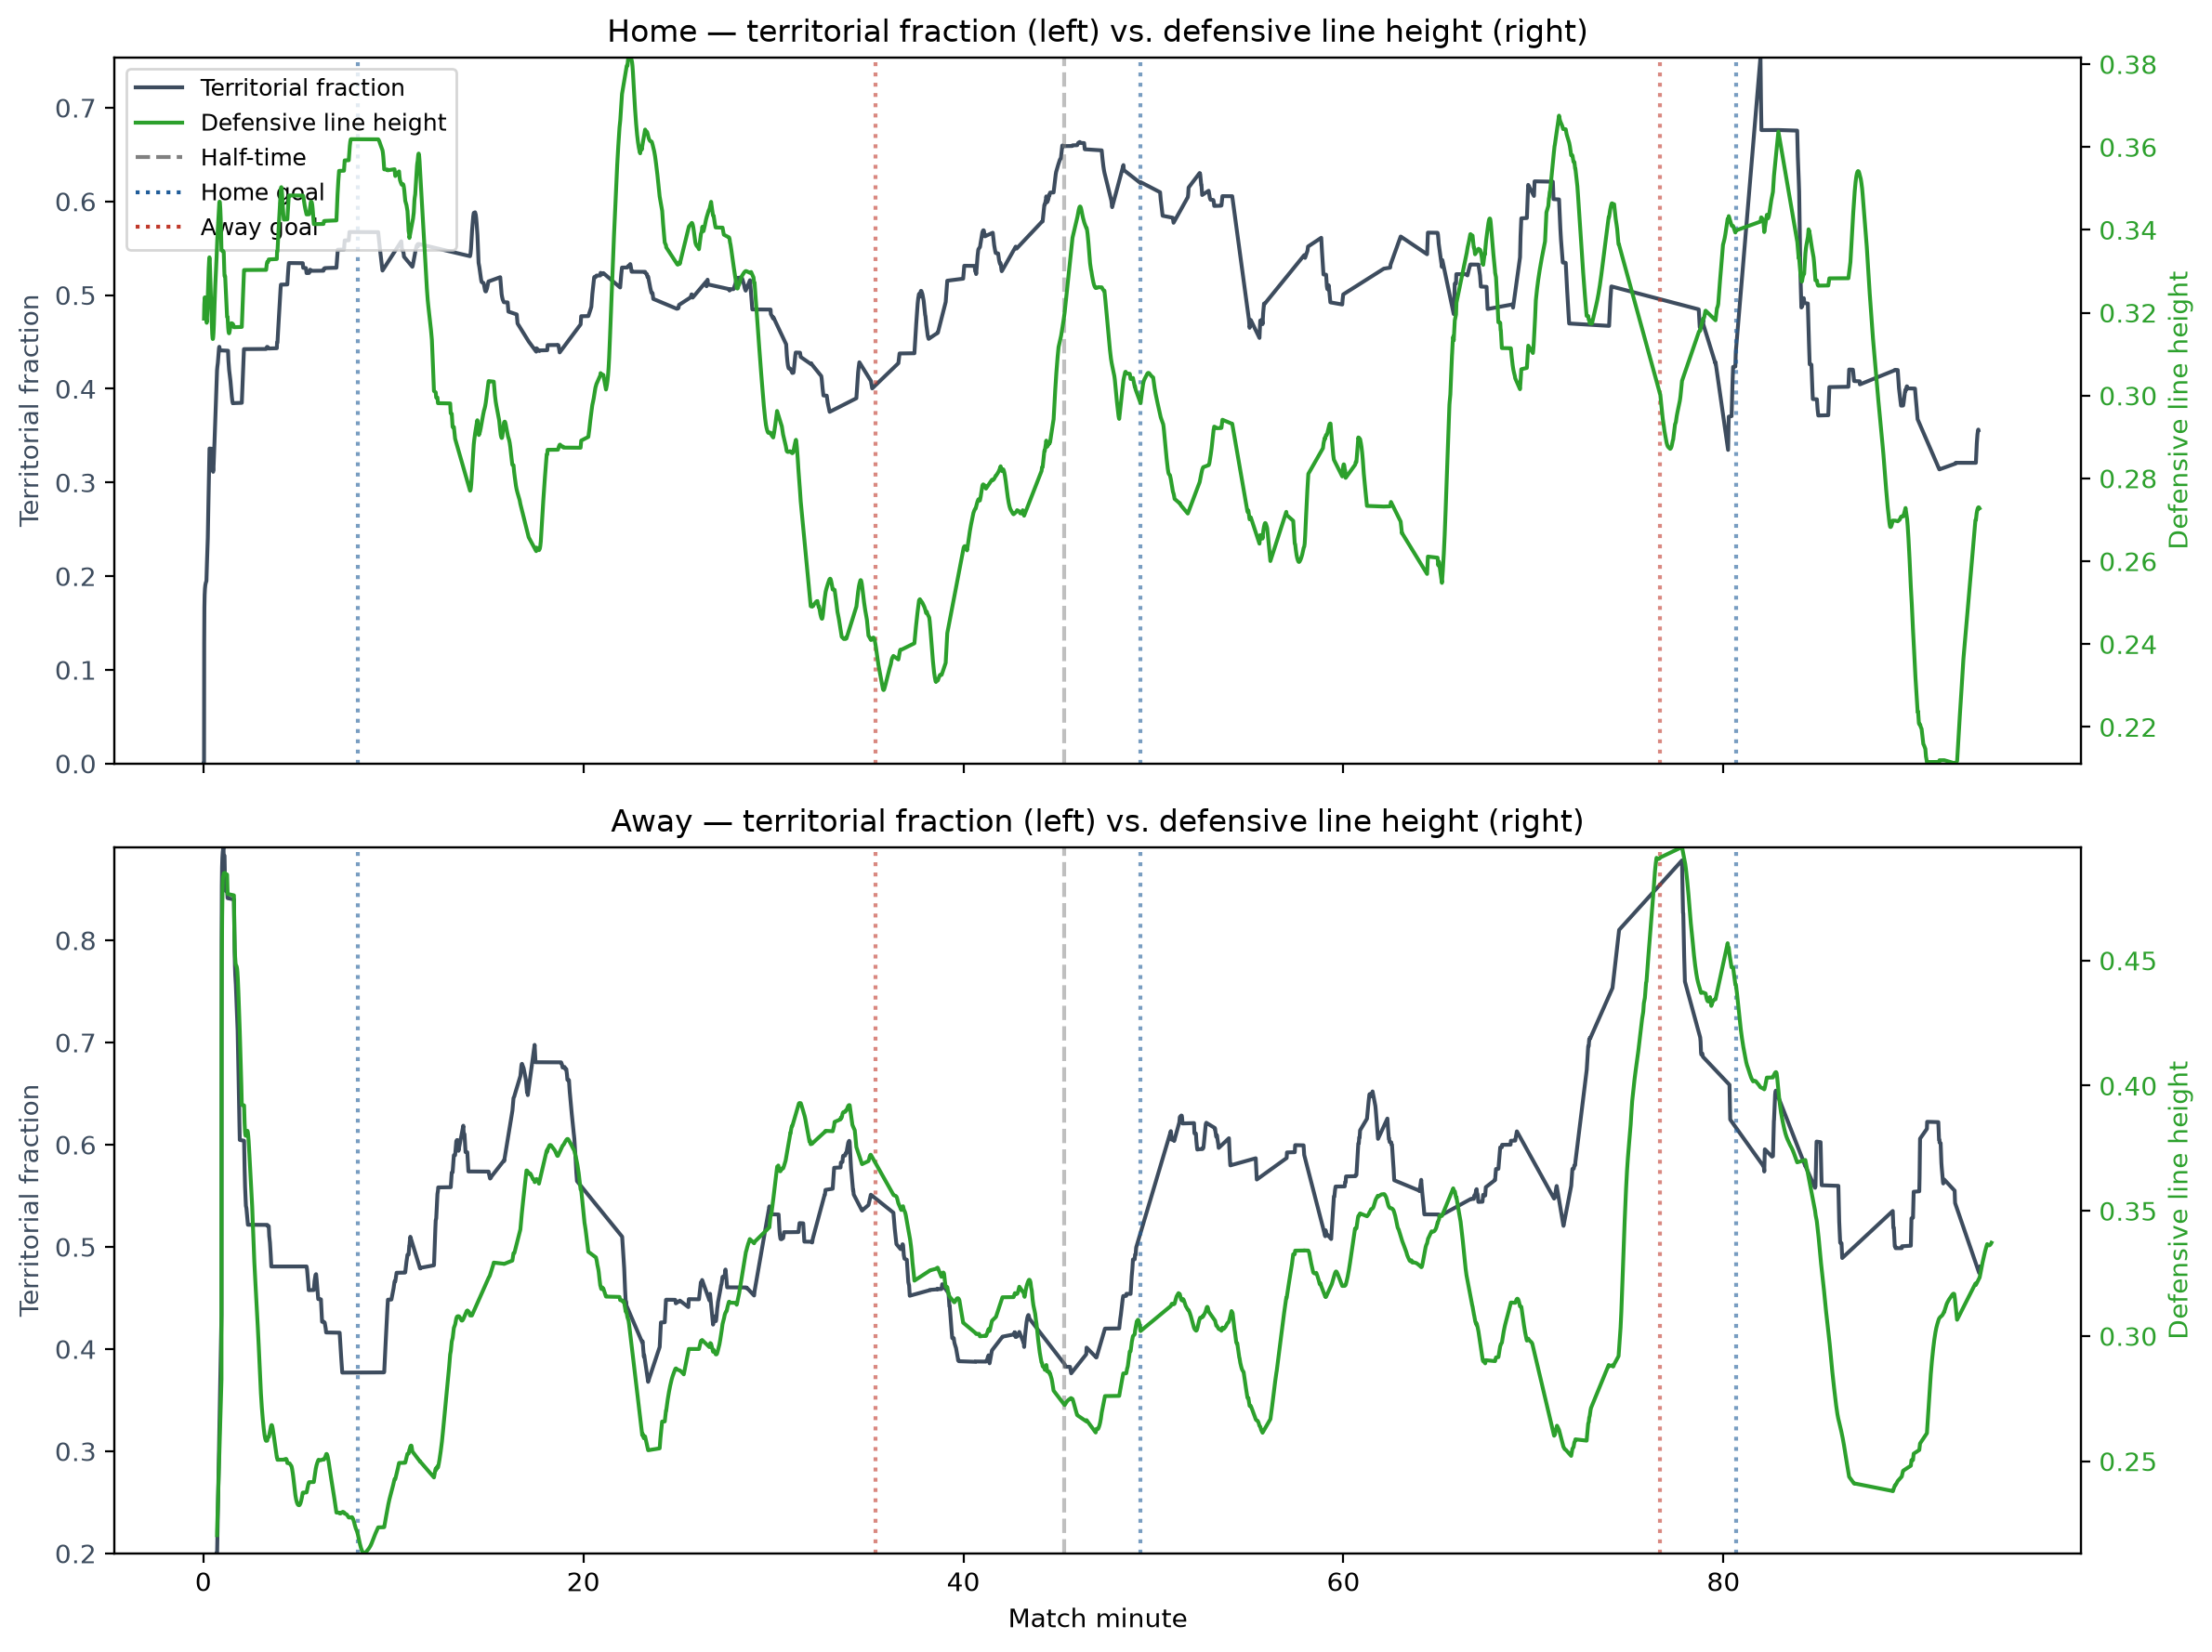

In [11]:
def rolling_range(x, y):
    valid = ~np.isnan(y)
    return y[valid].min(), y[valid].max()


fig, (ax_home, ax_away) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

panels = [
    (ax_home, home_x, home_rolled, home_dl_x, home_dl_rolled, "Home"),
    (ax_away, away_x, away_rolled, away_dl_x, away_dl_rolled, "Away"),
]

TERRITORIAL_COLOR = "#3D4C5E"
DEFLINE_COLOR = "#2ca02c"

for ax, terr_x, terr_y, dl_x, dl_y, team_name in panels:
    ax.plot(terr_x, terr_y, color=TERRITORIAL_COLOR)
    ax.set_ylabel("Territorial fraction", color=TERRITORIAL_COLOR)
    ax.tick_params(axis="y", labelcolor=TERRITORIAL_COLOR)
    ax.set_ylim(*rolling_range(terr_x, terr_y))

    ax2 = ax.twinx()
    ax2.plot(dl_x, dl_y, color=DEFLINE_COLOR)
    ax2.set_ylabel("Defensive line height", color=DEFLINE_COLOR)
    ax2.tick_params(axis="y", labelcolor=DEFLINE_COLOR)
    ax2.set_ylim(*rolling_range(dl_x, dl_y))

    ax.axvline(half_time_minute, color="grey", linestyle="--", alpha=0.5)
    for g in home_goal_minutes:
        ax.axvline(g, color="#1F5C99", linestyle=":", alpha=0.6)
    for g in away_goal_minutes:
        ax.axvline(g, color="#C0392B", linestyle=":", alpha=0.6)

    ax.set_title(f"{team_name} — territorial fraction (left) vs. defensive line height (right)")

ax_away.set_xlabel("Match minute")

combined_legend = [
    Line2D([0], [0], color=TERRITORIAL_COLOR, label="Territorial fraction"),
    Line2D([0], [0], color=DEFLINE_COLOR, label="Defensive line height"),
    Line2D([0], [0], color="grey", linestyle="--", label="Half-time"),
    Line2D([0], [0], color="#1F5C99", linestyle=":", label="Home goal"),
    Line2D([0], [0], color="#C0392B", linestyle=":", label="Away goal"),
]
ax_home.legend(handles=combined_legend, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

Both panels show the same basic shape doing the same thing at the same time far more often than not — when one line rises through the middle of the match, the other tends to as well, and both spike together in the 68-82 minute stretch already flagged above as the moment the scoreline was live. Away's two peaks land at almost the exact same minute (77.8 for both territorial fraction and defensive line height), which is about as close to independent confirmation as two differently-constructed metrics can give on a single match.

The agreement isn't total, and it doesn't need to be for validation purposes — Home's defensive line spikes early, around minute 22, well before its territorial-fraction peak near minute 82, a stretch where the two clearly aren't moving together. But the more the two curves broadly coincide, the more confidence there is that territorial fraction is tracking something real about team positioning rather than an artifact of how it happens to be constructed — which is what a defensive-line-height comparison, using a completely independent, long-established definition, is actually being asked to check here.

In [12]:
from scipy.stats import pearsonr


def one_minute_bins(df, mask, col):
    sub = df.loc[mask, ["match_min", col]].dropna().copy()
    sub["minute"] = sub["match_min"].astype(int)
    return sub.groupby("minute")[col].mean()


home_terr_binned = one_minute_bins(home, home["opponent_has_ball"] & home["ball_in_opp_half"], "territorial_fraction")
home_dl_binned = one_minute_bins(home, home["opponent_has_ball"], "def_line")
away_terr_binned = one_minute_bins(away, away["opponent_has_ball"] & away["ball_in_opp_half"], "territorial_fraction")
away_dl_binned = one_minute_bins(away, away["opponent_has_ball"], "def_line")

home_common = home_terr_binned.index.intersection(home_dl_binned.index)
away_common = away_terr_binned.index.intersection(away_dl_binned.index)

r_home, p_home = pearsonr(home_terr_binned[home_common], home_dl_binned[home_common])
r_away, p_away = pearsonr(away_terr_binned[away_common], away_dl_binned[away_common])

print(f"Home — r = {r_home:.3f}, p = {p_home:.1e}, n = {len(home_common)} one-minute bins")
print(f"Away — r = {r_away:.3f}, p = {p_away:.1e}, n = {len(away_common)} one-minute bins")

Home — r = 0.710, p = 1.2e-13, n = 81 one-minute bins
Away — r = 0.730, p = 3.5e-14, n = 78 one-minute bins


Binning both series into one-minute means (to avoid treating 25 highly autocorrelated frames per second as 25 independent data points) gives r = 0.71 for Home and r = 0.73 for Away, both strongly positive. The p-values above shouldn't be read too literally — even one-minute bins aren't fully independent observations within a single continuous match — but the coefficients themselves are a reasonably honest summary: a strong, not perfect, positive relationship, which is exactly the validation this section set out to check. Two metrics built from completely different definitions, on completely different aspects of player positioning, agree closely enough to trust that territorial fraction is measuring something real.

# Conclusion: why event and tracking data don't tell quite the same story

Putting the pieces together: territorial fraction, taken at face value, disagreed with the main event-based finding — Away edged out Home overall, not the other way around. Investigating why pointed to scoreline rather than baseline style: Home spent most of its qualifying moments leading, Away spent most of its trailing, and each team's territorial fraction responds to being in that state, not just to who they are. Once scoreline is held constant by comparing both teams' figures only when the match was level, the gap reverses to match the event-data direction, and by a wider margin than the raw numbers showed in the other direction.

The mechanism behind that reversal is worth spelling out. Territorial fraction only measures where players are standing, not what they are trying to do — it has no way to distinguish a team that pushed forward to actively press the ball from a team that ended up in the opponent's half because the side in possession chose to keep the ball in deep, safe areas and simply drew the out-of-possession team up the pitch after it. A leading team can do exactly that: sit on the ball, invite the chasing team forward, and never make an active pressing decision at all. Forward press rate, in the event data analysis notebook, doesn't have this ambiguity, because it only counts logged defensive-action attempts — a team cannot accumulate those passively.

The broader lesson generalizes past this one match: event data and tracking data are not two ways of measuring the same underlying construct, even when the metrics built from them are designed to mirror each other as closely as possible. Event-based metrics like forward press rate are intrinsically behavioral — they can only register what a team actively did. Position-based tracking metrics like territorial fraction are intrinsically situational — they register where a team ended up, regardless of whether it got there by choice or by being drawn there. Both are legitimate signals of territorial aggression, but they can point in different directions in exactly the matches where scoreline and game state are doing a lot of the work, which is precisely when relying on only one of them would be misleading. That is the practical case for combining the two rather than treating either as a stand-alone proxy for 'aggression.'